## Comparación de Modelos

Una vez ajustados los dos modelos, comparamos sus desempeños.

In [8]:
import polars as pl
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, roc_curve
import pyprojroot
import matplotlib.pyplot as plt
ROOT = pyprojroot.here()

In [6]:
datos_con_predicciones = pl.read_parquet(ROOT / "Datos" / "datos_con_predicciones.parquet")

swing_real = datos_con_predicciones["Swing"].to_numpy()
prob_xgboost = datos_con_predicciones["probabilidades_xgb"].to_numpy()
prob_regresion = datos_con_predicciones["probabilidades_regresion"].to_numpy()

# Calculamos las métricas para el Modelo XGBoost
logloss_1 = log_loss(swing_real, prob_xgboost)
brier_1 = brier_score_loss(swing_real, prob_xgboost)
auc_1 = roc_auc_score(swing_real, prob_xgboost)

# Calculamos las métricas para el Modelo 2
logloss_2 = log_loss(swing_real, prob_regresion)
brier_2 = brier_score_loss(swing_real, prob_regresion)
auc_2 = roc_auc_score(swing_real, prob_regresion)

# Armamos la tabla comparativa directamente en Polars
tabla_comparativa = pl.DataFrame({
    "Métrica": ["Log-Loss", "Brier Score", "AUC-ROC"],
    "XGBoost": [round(logloss_1, 4), round(brier_1, 4), round(auc_1, 4)],
    "Regresión": [round(logloss_2, 4), round(brier_2, 4), round(auc_2, 4)]
})

# Mostramos la tabla
print("--- COMPARACIÓN DE MODELOS ---")
print(tabla_comparativa)

--- COMPARACIÓN DE MODELOS ---
shape: (3, 3)
┌─────────────┬─────────┬───────────┐
│ Métrica     ┆ XGBoost ┆ Regresión │
│ ---         ┆ ---     ┆ ---       │
│ str         ┆ f64     ┆ f64       │
╞═════════════╪═════════╪═══════════╡
│ Log-Loss    ┆ 0.0767  ┆ 0.5731    │
│ Brier Score ┆ 0.0167  ┆ 0.1928    │
│ AUC-ROC     ┆ 0.9962  ┆ 0.7685    │
└─────────────┴─────────┴───────────┘


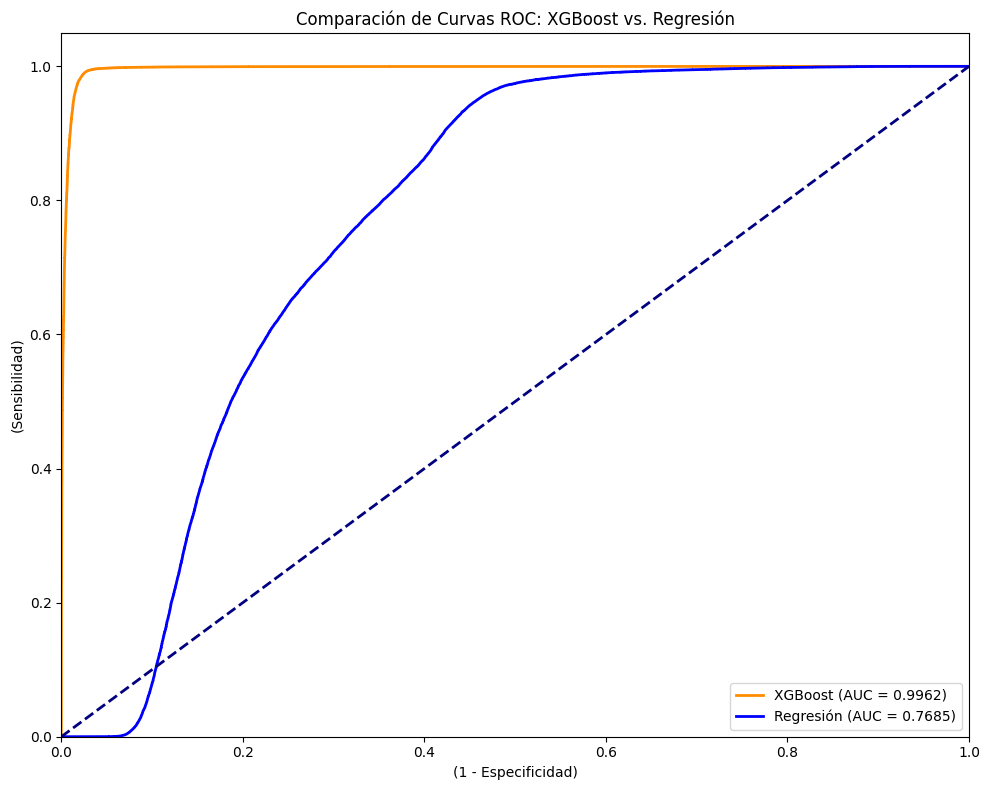

In [9]:
# Modelo XGBoost
fpr1, tpr1, _ = roc_curve(swing_real, prob_xgboost)
auc1 = roc_auc_score(swing_real, prob_xgboost)

# Regresión
fpr2, tpr2, _ = roc_curve(swing_real, prob_regresion)
auc2 = roc_auc_score(swing_real, prob_regresion)

plt.figure(figsize = (10, 8))

# Graficamos la curva del Modelo XGBoost
plt.plot(fpr1, tpr1, color = 'darkorange', lw = 2, label = f'XGBoost (AUC = {auc1:.4f})')

# Graficamos la curva de la Regresión
plt.plot(fpr2, tpr2, color = 'blue', lw = 2, label = f'Regresión (AUC = {auc2:.4f})')

plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('(1 - Especificidad)')
plt.ylabel('(Sensibilidad)')
plt.title('Comparación de Curvas ROC: XGBoost vs. Regresión')
plt.legend(loc = "lower right")

# Mostramos el gráfico
plt.tight_layout()
plt.show()

Analizando las métricas calculadas, observamos que el modelo XGBoost presenta un rendimiento superior que el modelo de regresión logística.

Por lo tanto, el modelo XGBoost es el elegido para predecir los valores de la temporada 2.